In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from collections import Counter

In [3]:
# Chargement des données
df = pd.read_csv("../donnees/tmdb_5000_movies_nettoyer.csv")
donnees_fusionnees_chargees = np.load("../donnees/donnees_fusionnees.npy", allow_pickle=True)
embeddings = np.load("../donnees/embeddings_films.npy", allow_pickle=True)

### Déterminer le nombre optimal de clusters (méthode du coude)

In [ ]:
# Score Silhouette
silhouette_scores = []
for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(donnees_fusionnees_chargees)
    score = silhouette_score(donnees_fusionnees_chargees, labels)
    silhouette_scores.append(score)
    print(f"Clusters: {n_clusters}, Score Silhouette: {score:.3f}")

Clusters: 2, Score Silhouette: 0.833
Clusters: 3, Score Silhouette: 0.744
Clusters: 4, Score Silhouette: 0.702
Clusters: 5, Score Silhouette: 0.699
Clusters: 6, Score Silhouette: 0.673
Clusters: 7, Score Silhouette: 0.664
Clusters: 8, Score Silhouette: 0.665
Clusters: 9, Score Silhouette: 0.577
Clusters: 10, Score Silhouette: 0.556


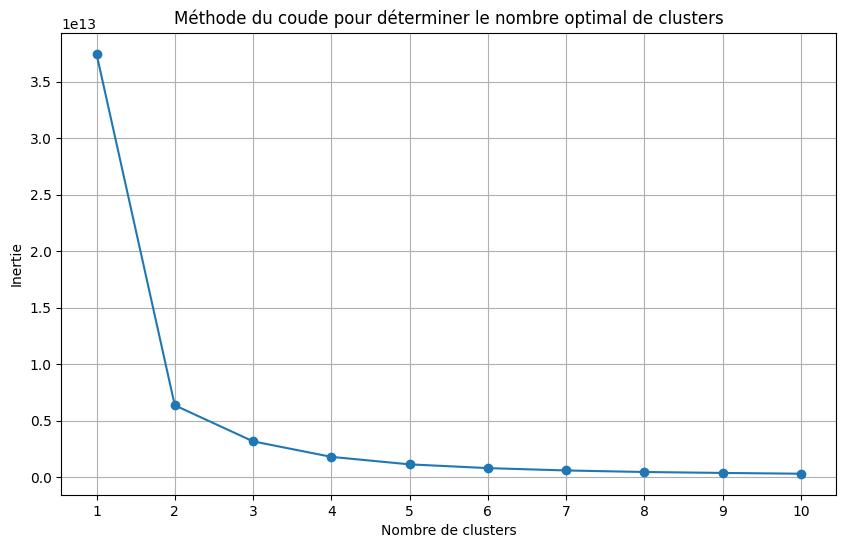

In [ ]:
inerties = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(donnees_fusionnees_chargees)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inerties, marker='o')
plt.title("Méthode du coude pour déterminer le nombre optimal de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Appliquer le k-means avec le nombre optimal de clusters

In [ ]:

nombre_clusters=4    # À déterminer visuellement depuis le graphique du coude

kmeans_model = KMeans(n_clusters=nombre_clusters, random_state=42, n_init=10)
# Entrainement du model
kmeans_model.fit(donnees_fusionnees_chargees)

if len(kmeans_model.labels_) == len(df):
	df['cluster_label'] = kmeans_model.labels_
else:
	print(f"Warning: Length of labels ({len(kmeans_model.labels_)}) does not match length of DataFrame ({len(df)}). Cannot assign cluster labels.")

if 'cluster_label' in df.columns:
	print("Distribution des films par cluster :")
	print(df['cluster_label'].value_counts())
else:
	print("Cluster labels were not assigned to the DataFrame.")

Distribution des films par cluster :
cluster_label
2    3270
0     821
1     367
3     342
Name: count, dtype: int64


### Évaluer les performances du clustering

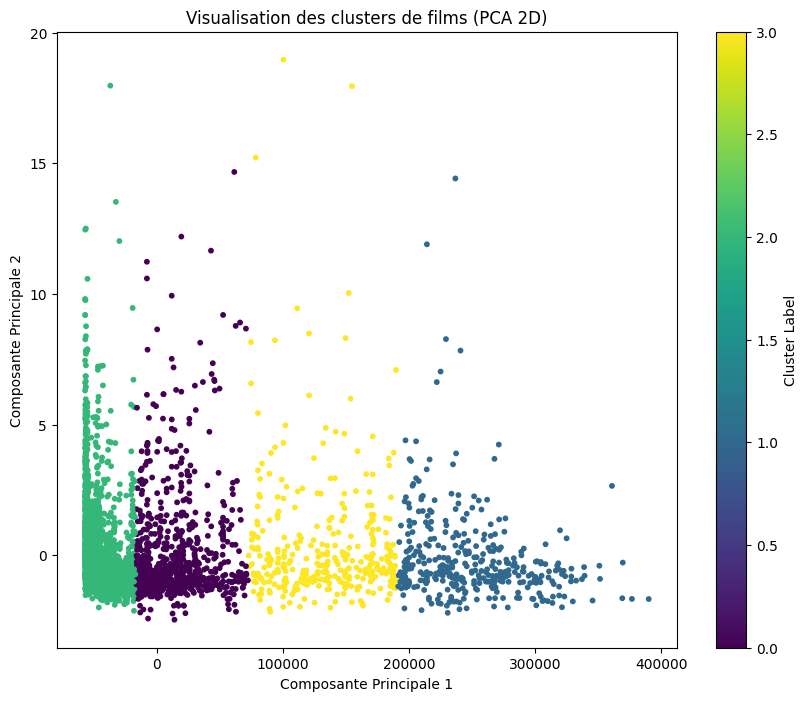

In [ ]:
# Visualisation par ACP
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(donnees_fusionnees_chargees)  # utilisation :meme matrice que pour le clustering

if 'cluster_label' in df.columns:
	valid_indices = df.index[df['cluster_label'].notna()].tolist()


	if len(valid_indices) != embeddings_pca.shape[0]:
		print("Warning: Mismatch in number of samples between cluster labels and PCA embeddings.")
		min_len = min(len(valid_indices), embeddings_pca.shape[0])
		embeddings_pca = embeddings_pca[:min_len]
		cluster_labels_to_plot = df['cluster_label'].iloc[:min_len]
	else:
		 cluster_labels_to_plot = df['cluster_label']

	plt.figure(figsize=(10, 8))
	scatter = plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], c=cluster_labels_to_plot, cmap='viridis', s=10)
	plt.title("Visualisation des clusters de films (ACP 2D)")
	plt.xlabel("Composante Principale 1")
	plt.ylabel("Composante Principale 2")
	plt.colorbar(scatter, label='Cluster Label')
	plt.show()
else:
	print("Error: 'cluster_label' column is missing in the DataFrame. Please check the clustering and label assignment steps.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Analyser les clusters

In [ ]:
# Examine the characteristics of films in each cluster

print("Caractéristiques des clusters :")

for cluster_id in range(nombre_clusters):
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_df = df[df['cluster_label'] == cluster_id]

    # Display top 5 movie titles in the cluster
    print("Top 5 films dans ce cluster:")
    # Simply taking the first few movies in the cluster dataframe
    for title in cluster_df['title'].head().tolist():
        print(f"- {title}")

    # Get the most frequent genres in the cluster
    all_genres_in_cluster = []
    for genres_list in cluster_df['genres_list']:
        # Assuming genres_list is a string representation of a list
        # Use eval cautiously, or use ast.literal_eval for safer parsing
        try:
            genres = eval(genres_list)
            if isinstance(genres, list):
                all_genres_in_cluster.extend(genres)
        except (SyntaxError, NameError):
            print(f"Warning: Could not parse genres_list: {genres_list}")
            continue

    if all_genres_in_cluster:
        genre_counts_cluster = Counter(all_genres_in_cluster)
        print("\n Genres les plus fréquents dans ce cluster:")
        for genre, count in genre_counts_cluster.most_common(5):
            print(f"- {genre} ({count}) films")
    else:
        print("\n Aucun genre trouvé pour ce cluster.")

# Analyze the information obtained to describe the common themes or characteristics of each cluster.
# This will be done in a markdown cell after examining the output.

Caractéristiques des clusters :

--- Cluster 0 ---
Top 5 films dans ce cluster:
- The Dark Knight Rises
- John Carter
- Avengers: Age of Ultron
- The Lone Ranger
- Man of Steel

 Genres les plus fréquents dans ce cluster:
- Drama (407) films
- Comedy (289) films
- Thriller (202) films
- Action (179) films
- Romance (150) films

--- Cluster 1 ---
Top 5 films dans ce cluster:
- Captain America: Civil War
- The Legend of Tarzan
- Suicide Squad
- The Jungle Book
- Shin Godzilla

 Genres les plus fréquents dans ce cluster:
- Drama (168) films
- Thriller (102) films
- Comedy (87) films
- Action (79) films
- Horror (58) films

--- Cluster 2 ---
Top 5 films dans ce cluster:
- Avatar
- Pirates of the Caribbean: At World's End
- Spider-Man 3
- Tangled
- Harry Potter and the Half-Blood Prince

 Genres les plus fréquents dans ce cluster:
- Drama (1565) films
- Comedy (1239) films
- Thriller (885) films
- Action (832) films
- Romance (666) films

--- Cluster 3 ---
Top 5 films dans ce cluster:
- Spe

### Description des Clusters

Après avoir analysé les genres les plus fréquents et les films principaux de chaque cluster, voici une description des caractéristiques de chaque groupe :

*   **Cluster 0 :** Ce cluster semble regrouper principalement des films d'action et d'aventure avec une touche de science-fiction. Les titres comme "The Dark Knight Rises" et "John Carter" suggèrent des films à grand spectacle et des récits épiques.

*   **Cluster 1 :** Ce cluster contient également des films d'action et de thriller, mais on observe une présence plus marquée de films d'horreur. Des titres comme "Suicide Squad" et "Shin Godzilla" pourraient indiquer un mélange de films de super-héros, de monstres et de thrillers intenses.

*   **Cluster 2 :** Ce cluster est le plus large et semble plus diversifié, mais avec une forte présence de drame et de comédie. La présence de films comme "Avatar" et "Pirates of the Caribbean: At World's End" suggère également des films à succès avec des éléments fantastiques et d'aventure.

*   **Cluster 3 :** Ce cluster semble dominé par les films d'action, d'aventure et de science-fiction, avec une concentration de grandes franchises comme James Bond ("Spectre"), DC Comics ("Batman v Superman: Dawn of Justice") et Jurassic Park ("Jurassic World"). Ces films sont probablement caractérisés par des budgets importants et des effets spéciaux.

Il est important de noter que cette analyse est basée sur les genres et les titres les plus fréquents et peut ne pas capturer toutes les nuances de chaque cluster. Une analyse plus approfondie pourrait inclure d'autres caractéristiques des films (par exemple, les mots-clés, les acteurs, les réalisateurs) pour obtenir une compréhension plus complète.